# Payoff structures — NIFTY options

Straddle · strangle · **vertical spreads (credit and debit)** · iron fly · iron condor ·
naked call and put.

One trading day: **27 Jan 2026**, expiry **10 Feb 2026**, lot size **65**.

The forward and the discount are derived from the option prices, not read from the data — see
[`docs/calculations.md`](../docs/calculations.md).

A strategy is a **list of legs**. Every figure below comes from one payoff function and one
metrics function — no per-strategy code.

**Every structure is drawn twice**, once anchored on spot and once on the forward. The two
anchors select different at-the-money strikes, so they are two different positions rather than
two views of one.

## 1. Setup

In [1]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE = ROOT / "Data" / "sample" / "chain_2026-01-27.parquet"

# NIFTY lot size, confirmed 65 on 19 Aug 2026 (map #1). Margin mechanics stay open in issue #4.
LOT_SIZE = 65

TRADING_DAYS_PER_YEAR = 252  # established in issue #2

## 2. The data

NIFTY option chain, 1-minute bars, one session.

- `ts` is **UTC**. Source options are IST stamped at bar close, greeks UTC at bar open — a naive join
  returns zero rows and no warning.
- `dte_days` is a **trading-day clock**: one session consumes exactly 1.0, overnight and weekends none.
- Prices are the bar close, which is what `last` holds.

In [2]:
chain = pd.read_parquet(SAMPLE)
chain["ist"] = chain.ts + pd.Timedelta(hours=5, minutes=30)

print(f"rows      {len(chain):,}")
print(f"session   {chain.ist.min():%H:%M} -> {chain.ist.max():%H:%M} IST on {chain.ist.dt.date.iloc[0]}")
print(f"strikes   {chain.strike.nunique()}  ({chain.strike.min():.0f} - {chain.strike.max():.0f})")
print(f"dte_days  {chain.dte_days.max():.4f} at open -> {chain.dte_days.min():.4f} at close")
chain.head(3)

rows      23,581
session   09:15 -> 15:30 IST on 2026-01-27
strikes   94  (23300 - 27950)
dte_days  11.0000 at open -> 10.0000 at close


,ts,strike,option_type,Open,High,Low,Close,Volume,OpenInterest,Ticker,...,delta,gamma,theta,vega,rho,vanna,volga,charm,spot,ist
0,2026-01-27 03:45:00,23350.0,PE,19.15,19.35,19.0,19.0,1170,0,NIFTY10FEB2623350PE.NFO,...,-0.040644,0.000077,-4.294955,4.589929,-0.454762,-0.006859,0.628664,0.006734,25113.05,2026-01-27 09:15:00
1,2026-01-27 03:45:00,23400.0,PE,22.05,22.25,20.5,20.5,1755,20280,NIFTY10FEB2623400PE.NFO,...,-0.043716,0.000082,-4.531928,4.868650,-0.489155,-0.007188,0.645895,0.007020,25113.05,2026-01-27 09:15:00
2,2026-01-27 03:45:00,23450.0,PE,23.75,23.75,21.4,21.4,1820,4355,NIFTY10FEB2623450PE.NFO,...,-0.045958,0.000087,-4.658043,5.068765,-0.514183,-0.007489,0.663581,0.007221,25113.05,2026-01-27 09:15:00


### Moment

Midday IST — liquid, clear of the open and close auctions.

In [3]:
SNAPSHOT_TIME = pd.Timestamp("2026-01-27 12:00:00")

snap = chain[chain.ist == SNAPSHOT_TIME].copy()

SPOT = float(snap.spot.iloc[0])
DTE  = float(snap.dte_days.iloc[0])
T    = DTE / TRADING_DAYS_PER_YEAR

# Not inputs. Section 3 derives the forward and the discount from the option prices and
# grades the result against these two columns.
SOURCE_FORWARD  = float(snap.forward.iloc[0])
SOURCE_DISCOUNT = float(snap.discount.iloc[0])

print(f"spot      {SPOT:,.2f}")
print(f"dte_days  {DTE:.4f}   ->  T = {DTE:.4f}/252 = {T:.6f} years")
print(f"legs available: {len(snap)} across {snap.strike.nunique()} strikes")

spot      25,100.25
dte_days  10.5600   ->  T = 10.5600/252 = 0.041905 years
legs available: 58 across 49 strikes


## 3. Implied forward and discount

The forward and the discount factor are **derived from the option prices**, not read from the
data. Full derivation in [`docs/calculations.md`](../docs/calculations.md).

Put-call parity is an identity for European options on the same underlying, strike and expiry.
No model, no volatility, no distributional assumption:

$$C(K) - P(K) = D\,(F - K)$$

Read as a function of $K$ it is already a straight line:

$$\underbrace{C(K) - P(K)}_{y} \;=\; \underbrace{DF}_{a} \;+\; \underbrace{(-D)}_{b}\,K$$

So one ordinary least squares fit of $y$ on $K$ recovers both unknowns at once:

$$\hat D = -b \qquad \hat F = \frac{a}{\hat D} = -\frac{a}{b}$$

Only strikes quoting **both** a call and a put can enter — parity needs a pair.

**The gate.** OLS returns a number whether the input deserves one or not, so a fit is used only
if $n \ge 5$ and the implied rate $\hat r = -\ln \hat D / T$ falls inside $(0\%,\ 30\%)$.
Rejected minutes give $\hat D$ above 1 — a negative rate over two weeks — which would render as
a plausible-looking chart that is wrong. Those minutes are out of scope for v1 and are not
shown.

In [4]:
pairs = snap.pivot_table(index="strike", columns="option_type", values="last").dropna()
K = pairs.index.to_numpy(float)
y = (pairs.CE - pairs.PE).to_numpy(float)

b, a = np.polyfit(K, y, 1)           # y = a + b*K
DISCOUNT = -b
FORWARD = a / DISCOUNT
RATE = -np.log(DISCOUNT) / T
r2 = np.corrcoef(K, y)[0, 1] ** 2

assert len(pairs) >= 5, f"only {len(pairs)} paired strikes - fit rejected"
assert 0 < RATE < 0.30, f"implied rate {RATE:.2%} outside (0%, 30%) - fit rejected"

print(f"paired strikes   {len(pairs)}   ({K.min():,.0f} - {K.max():,.0f})")
print(f"fit              C - P = {a:,.2f} + {b:.6f} K      R2 = {r2:.6f}")
print(f"discount         {DISCOUNT:.6f}")
print(f"forward          {FORWARD:,.2f}    (basis {FORWARD - SPOT:+.2f} points over spot)")
print(f"implied rate     {RATE:.2%}   gate (0%, 30%): pass")

# Graded against the two columns solved independently upstream.
print()
print(f"{'':<12}{'ours':>14}{'source':>14}{'diff':>12}")
print(f"{'discount':<12}{DISCOUNT:>14.6f}{SOURCE_DISCOUNT:>14.6f}{DISCOUNT - SOURCE_DISCOUNT:>+12.6f}")
print(f"{'forward':<12}{FORWARD:>14,.2f}{SOURCE_FORWARD:>14,.2f}{FORWARD - SOURCE_FORWARD:>+12.2f}")
assert abs(FORWARD - SOURCE_FORWARD) < 0.01, "forward disagrees with the source"
assert abs(DISCOUNT - SOURCE_DISCOUNT) < 1e-6, "discount disagrees with the source"

paired strikes   9   (24,500 - 25,500)
fit              C - P = 25,054.69 + -0.993480 K      R2 = 0.999892
discount         0.993480
forward          25,219.12    (basis +118.87 points over spot)
implied rate     15.61%   gate (0%, 30%): pass

                      ours        source        diff
discount          0.993480      0.993480   +0.000000
forward          25,219.12     25,219.12       +0.00


### Two anchors

The at-the-money strike is the one nearest the **forward**, not the spot. Here the two differ by
more than two strike intervals and select different strikes — so this is not a rounding detail,
it changes which options every structure below holds.

Rather than assert that once, the notebook builds **both** and draws both. Wherever the two
panels disagree, the basis $\hat F - S$ is the reason.

In [5]:
quoted_both = sorted(snap.groupby("strike").option_type.nunique().pipe(lambda q: q[q == 2]).index)
atm_from_spot    = min(quoted_both, key=lambda k: abs(k - SPOT))
atm_from_forward = min(quoted_both, key=lambda k: abs(k - FORWARD))

print(f"spot      {SPOT:,.2f}   -> nearest paired strike {atm_from_spot:,.0f}")
print(f"forward   {FORWARD:,.2f}   -> nearest paired strike {atm_from_forward:,.0f}")
print(f"basis     {FORWARD - SPOT:+.2f} points")

# If these ever coincide the two panels below collapse into one chart drawn twice.
assert atm_from_forward != atm_from_spot, "the anchors agree - the paired charts would be identical"
print(f"the anchors disagree: {atm_from_forward:,.0f} (forward) vs {atm_from_spot:,.0f} (spot)")

spot      25,100.25   -> nearest paired strike 25,100
forward   25,219.12   -> nearest paired strike 25,200
basis     +118.87 points
the anchors disagree: 25,200 (forward) vs 25,100 (spot)


## 4. Legs and strategies

A **leg** is one contract: strike, type, direction, quantity, entry price.
A **strategy** is a list of legs — an iron condor is four legs, not a type.

In [6]:
@dataclass(frozen=True)
class Leg:
    strike: float
    option_type: str      # "CE" or "PE"
    direction: int        # +1 bought, -1 sold
    entry_price: float
    iv: float
    quantity: int = 1

    @property
    def is_call(self):
        return self.option_type == "CE"

    def __repr__(self):
        side = "B" if self.direction > 0 else "S"
        return f"{side} {self.quantity}x {self.strike:.0f} {self.option_type} @ {self.entry_price:.2f}"


def leg_from_chain(strike, option_type, direction, quantity=1, snapshot=None):
    '''Build a Leg from the observed chain. Entry price is the 1-min bar close.'''
    snapshot = snap if snapshot is None else snapshot
    row = snapshot[(snapshot.strike == strike) & (snapshot.option_type == option_type)]
    if row.empty:
        raise KeyError(f"{strike:.0f} {option_type} not quoted at this minute")
    row = row.iloc[0]
    return Leg(strike, option_type, direction, float(row.last), float(row.iv), quantity)

### Strikes

Two at-the-money strikes, one per anchor, and every structure built at each.

Outer legs sit at the **nearest quoted strike at least $w$ points away**, not at
$\text{ATM} \pm w$ — the chain has gaps and an unquoted strike cannot be traded. That is why the
same nominal structure can come out with different widths under the two anchors.

In [7]:
quoted = snap.groupby("strike").option_type.nunique()
both_sides = set(quoted[quoted == 2].index)          # strikes with a live CE and PE

# A fly or condor wing is a single option, so it does not need the strike quoted on both sides -
# and at this minute nothing above 25,500 is. Restricting the wings to `both_sides` would leave
# the far call wing unbuildable.
ce_strikes = set(snap.loc[snap.option_type == "CE", "strike"])
pe_strikes = set(snap.loc[snap.option_type == "PE", "strike"])

WING   = 300     # strangle
NEAR   = 300     # fly wings
FAR    = 600     # condor wings
SPREAD = 300     # vertical spreads


def build_strategies(atm):
    """Every structure in this notebook, built around one at-the-money strike."""
    otm_call = min(k for k in both_sides if k >= atm + WING)
    otm_put  = max(k for k in both_sides if k <= atm - WING)
    fly_call = min(k for k in ce_strikes if k >= atm + NEAR)
    fly_put  = max(k for k in pe_strikes if k <= atm - NEAR)
    con_call = min(k for k in ce_strikes if k >= atm + FAR)
    con_put  = max(k for k in pe_strikes if k <= atm - FAR)
    up_call  = min(k for k in ce_strikes if k >= atm + SPREAD)
    dn_put   = max(k for k in pe_strikes if k <= atm - SPREAD)

    strategies = {
        "Long Straddle":    [leg_from_chain(atm, "CE", +1), leg_from_chain(atm, "PE", +1)],
        "Short Straddle":   [leg_from_chain(atm, "CE", -1), leg_from_chain(atm, "PE", -1)],
        "Long Strangle":    [leg_from_chain(otm_call, "CE", +1), leg_from_chain(otm_put, "PE", +1)],
        # Vertical spreads. Same two strikes each time; the signs decide debit or credit.
        "Bull Call Spread": [leg_from_chain(atm, "CE", +1), leg_from_chain(up_call, "CE", -1)],
        "Bear Call Spread": [leg_from_chain(atm, "CE", -1), leg_from_chain(up_call, "CE", +1)],
        "Bull Put Spread":  [leg_from_chain(atm, "PE", -1), leg_from_chain(dn_put, "PE", +1)],
        "Bear Put Spread":  [leg_from_chain(atm, "PE", +1), leg_from_chain(dn_put, "PE", -1)],
        "Iron Fly":         [leg_from_chain(atm, "CE", -1), leg_from_chain(atm, "PE", -1),
                             leg_from_chain(fly_call, "CE", +1), leg_from_chain(fly_put, "PE", +1)],
        "Iron Condor":      [leg_from_chain(fly_call, "CE", -1), leg_from_chain(fly_put, "PE", -1),
                             leg_from_chain(con_call, "CE", +1), leg_from_chain(con_put, "PE", +1)],
        "Naked Long Call":  [leg_from_chain(atm, "CE", +1)],
        "Naked Short Call": [leg_from_chain(atm, "CE", -1)],
        "Naked Long Put":   [leg_from_chain(atm, "PE", +1)],
        "Naked Short Put":  [leg_from_chain(atm, "PE", -1)],
    }
    strikes = {"atm": atm, "otm_call": otm_call, "otm_put": otm_put,
               "fly_call": fly_call, "fly_put": fly_put,
               "con_call": con_call, "con_put": con_put,
               "up_call": up_call, "dn_put": dn_put}
    return strategies, strikes


ATM_FWD  = min(both_sides, key=lambda k: abs(k - FORWARD))
ATM_SPOT = min(both_sides, key=lambda k: abs(k - SPOT))

STRATEGIES_FWD,  STRIKES_FWD  = build_strategies(ATM_FWD)
STRATEGIES_SPOT, STRIKES_SPOT = build_strategies(ATM_SPOT)

ANCHORS = {
    "spot":    dict(level=SPOT,    atm=ATM_SPOT, strategies=STRATEGIES_SPOT, strikes=STRIKES_SPOT),
    "forward": dict(level=FORWARD, atm=ATM_FWD,  strategies=STRATEGIES_FWD,  strikes=STRIKES_FWD),
}

# The worked arithmetic in the markdown below is the forward-anchored position.
ATM = ATM_FWD
STRATEGIES = STRATEGIES_FWD


def pair(lo, hi):
    return f"{lo:,.0f} / {hi:,.0f}"


hdr = f"{'anchor':<9}{'level':>12}{'ATM':>9}{'strangle':>18}{'spread':>18}{'fly':>18}{'condor':>18}"
print(hdr)
print("-" * len(hdr))
for anchor, A in ANCHORS.items():
    s = A["strikes"]
    print(f"{anchor:<9}{A['level']:>12,.2f}{s['atm']:>9,.0f}"
          f"{pair(s['otm_put'], s['otm_call']):>18}"
          f"{pair(s['dn_put'], s['up_call']):>18}"
          f"{pair(s['fly_put'], s['fly_call']):>18}"
          f"{pair(s['con_put'], s['con_call']):>18}")

print(f"\nbasis {FORWARD - SPOT:+.2f} points -> the anchors disagree: {ATM_FWD != ATM_SPOT}")
for anchor, A in ANCHORS.items():
    print(f"\n{anchor} anchor, ATM {A['atm']:,.0f}")
    for name, legs in A["strategies"].items():
        print(f"  {name:<18} {legs}")

anchor          level      ATM          strangle            spread               fly            condor
------------------------------------------------------------------------------------------------------
spot        25,100.25   25,100   24,800 / 25,500   24,800 / 25,500   24,800 / 25,500   24,500 / 25,700
forward     25,219.12   25,200   24,800 / 25,500   24,900 / 25,500   24,900 / 25,500   24,600 / 25,800

basis +118.87 points -> the anchors disagree: True

spot anchor, ATM 25,100
  Long Straddle      [B 1x 25100 CE @ 402.35, B 1x 25100 PE @ 280.00]
  Short Straddle     [S 1x 25100 CE @ 402.35, S 1x 25100 PE @ 280.00]
  Long Strangle      [B 1x 25500 CE @ 206.20, B 1x 24800 PE @ 180.10]
  Bull Call Spread   [B 1x 25100 CE @ 402.35, S 1x 25500 CE @ 206.20]
  Bear Call Spread   [S 1x 25100 CE @ 402.35, B 1x 25500 CE @ 206.20]
  Bull Put Spread    [S 1x 25100 PE @ 280.00, B 1x 24800 PE @ 180.10]
  Bear Put Spread    [B 1x 25100 PE @ 280.00, S 1x 24800 PE @ 180.10]
  Iron Fly           

## 5. Payoff at expiry

At expiry the forward converges on the index, $F_T = S_T$: a position carried to expiry and the
index held outright settle at the same level. So the expiry payoff can be written in the forward,
and everything below is.

Notation, since both appear: $\hat F$ is the forward **now**, fitted in §3. $F$ is the forward
**at expiry** — the payoff variable, and the x-axis of every chart.

Intrinsic value only; all time value has decayed:

$$C_T = \max(F - K,\;0) \qquad P_T = \max(K - F,\;0)$$

Per leg, with direction $d = \pm 1$, quantity $q$, entry price $e$:

$$\Pi_{\text{leg}}(F) = d\,q\,\bigl(V(F) - e\bigr)$$

Strategy over $n$ legs at lot size $L$:

$$\Pi(F) \;=\; L \sum_{i=1}^{n} d_i\,q_i \bigl(V_i(F) - e_i\bigr)$$

One sum, any number of legs.

In [8]:
def intrinsic_value(terminal, strike, is_call):
    """Option value at expiry. `terminal` is F, the forward at expiry ( = the spot at expiry)."""
    terminal = np.asarray(terminal, float)
    return np.maximum(terminal - strike, 0.0) if is_call else np.maximum(strike - terminal, 0.0)


def payoff_at_expiry(terminal, legs, lot_size=1):
    """Strategy P&L at expiry, for a scalar or an array of terminal forwards."""
    total = np.zeros_like(np.asarray(terminal, float))
    for leg in legs:
        value = intrinsic_value(terminal, leg.strike, leg.is_call)
        total = total + leg.direction * leg.quantity * (value - leg.entry_price)
    return total * lot_size


# A long straddle must lose exactly the premium paid if the index settles on its strike.
for anchor, A in ANCHORS.items():
    legs = A["strategies"]["Long Straddle"]
    premium = sum(leg.direction * leg.quantity * leg.entry_price for leg in legs)
    at_strike = payoff_at_expiry(A["atm"], legs)
    assert np.isclose(at_strike, -premium)
    print(f"{anchor:<9} ATM {A['atm']:,.0f}   premium paid {premium:>8,.2f}   "
          f"P&L at F = {A['atm']:,.0f}: {float(at_strike):>9,.2f}   ok")

spot      ATM 25,100   premium paid   682.35   P&L at F = 25,100:   -682.35   ok
forward   ATM 25,200   premium paid   670.75   P&L at F = 25,200:   -670.75   ok


## 6. Max profit, max loss, breakevens

$\Pi$ is piecewise linear in $F$ and bends only at a strike, so the extremes are exact rather than
searched for. Candidate points:

$$\mathcal{K} = \{0\} \cup \{K_1, \dots, K_m\}$$

Tail slopes:

$$s_{\text{right}} = \sum_{\text{calls}} d_i q_i
\qquad
s_{\text{left}} = -\sum_{\text{puts}} d_i q_i$$

$$\text{max profit} =
\begin{cases}
\infty & s_{\text{right}} > 0\\[2pt]
\max_{F \in \mathcal{K}} \Pi(F) & \text{otherwise}
\end{cases}
\qquad
\text{max loss} =
\begin{cases}
-\infty & s_{\text{right}} < 0\\[2pt]
\min_{F \in \mathcal{K}} \Pi(F) & \text{otherwise}
\end{cases}$$

**Only the right tail is unbounded.** $F \ge 0$, so the left tail terminates — which is why $0$ is
a candidate point. A long put feels unlimited as the index collapses and is not: its profit stops
at $K - e$.

Breakevens: $\Pi$ is affine between adjacent candidates, so every sign change yields one root

$$F^{*} = F_j - \Pi(F_j)\,\frac{F_{j+1} - F_j}{\Pi(F_{j+1}) - \Pi(F_j)}$$

A strategy may have none, one or several. Both tails flat, $s_{\text{left}} = s_{\text{right}} = 0$,
means both caps are finite — that is what **defined risk** is, and it covers every vertical spread
and both iron structures below.

In [9]:
def strategy_metrics(legs, lot_size=1):
    strikes = sorted({leg.strike for leg in legs})

    right_slope = sum(leg.direction * leg.quantity for leg in legs if leg.is_call)
    left_slope  = -sum(leg.direction * leg.quantity for leg in legs if not leg.is_call)

    # candidates: every kink, plus F = 0 where the left tail terminates
    candidates = payoff_at_expiry(np.array([0.0] + strikes, float), legs, lot_size)

    # only the upside is genuinely unbounded - the index cannot fall below zero
    max_profit = np.inf if right_slope > 0 else float(candidates.max())
    max_loss = -np.inf if right_slope < 0 else float(candidates.min())

    # breakevens: fine scan for sign changes, then solve exactly inside each bracket
    pad = max(strikes[-1] - strikes[0], 1000) + 2000
    grid = np.linspace(0.0, strikes[-1] + pad, 20_000)
    pnl = payoff_at_expiry(grid, legs, lot_size)
    breakevens = []
    for i in np.where(np.sign(pnl[:-1]) * np.sign(pnl[1:]) < 0)[0]:
        root = brentq(lambda f: payoff_at_expiry(f, legs, lot_size), grid[i], grid[i + 1])
        breakevens.append(round(float(root), 2))

    net = sum(leg.direction * leg.quantity * leg.entry_price for leg in legs) * lot_size
    return {
        "max_profit": max_profit,
        "max_loss": max_loss,
        "breakevens": breakevens,
        "net_premium": net,          # positive = paid (debit), negative = received (credit)
        "left_slope": left_slope,
        "right_slope": right_slope,
    }


def fmt(x):
    if x == np.inf or x == -np.inf:
        return "Unlimited"
    return f"{x:,.0f}"


for anchor, A in ANCHORS.items():
    print(f"{anchor} anchor, ATM {A['atm']:,.0f}")
    for name, legs in A["strategies"].items():
        m = strategy_metrics(legs, LOT_SIZE)
        kind = "debit" if m["net_premium"] > 0 else "credit"
        risk = "defined" if m["left_slope"] == 0 and m["right_slope"] == 0 else "open tail"
        print(f"  {name:<18} max profit {fmt(m['max_profit']):>10}   "
              f"max loss {fmt(m['max_loss']):>10}   "
              f"net {abs(m['net_premium']):>9,.0f} {kind:<6} {risk:<9} "
              f"breakevens {m['breakevens']}")
    print()

spot anchor, ATM 25,100
  Long Straddle      max profit  Unlimited   max loss    -44,353   net    44,353 debit  open tail breakevens [24417.65, 25782.35]
  Short Straddle     max profit     44,353   max loss  Unlimited   net    44,353 credit open tail breakevens [24417.65, 25782.35]
  Long Strangle      max profit  Unlimited   max loss    -25,109   net    25,109 debit  open tail breakevens [24413.7, 25886.3]
  Bull Call Spread   max profit     13,250   max loss    -12,750   net    12,750 debit  defined   breakevens [25296.15]
  Bear Call Spread   max profit     12,750   max loss    -13,250   net    12,750 credit defined   breakevens [25296.15]
  Bull Put Spread    max profit      6,494   max loss    -13,006   net     6,494 credit defined   breakevens [25000.1]
  Bear Put Spread    max profit     13,006   max loss     -6,494   net     6,494 debit  defined   breakevens [25000.1]
  Iron Fly           max profit     19,243   max loss     -6,757   net    19,243 credit defined   breakevens [

## 7. The charts

Two panels per structure, $L = 65$:

| panel | at-the-money strike | x-axis centred on |
|---|---|---|
| left | nearest quoted strike to **spot** | $S$ |
| right | nearest quoted strike to **$\hat F$** | $\hat F$ |

They are **different positions**, not two renderings of one — the anchors pick different strikes,
so the premiums, caps and breakevens all move. Both lines are drawn on both panels; the anchor in
use is the solid one.

Green above zero, red below. Dotted vertical lines are breakevens.

The worked arithmetic under each heading is the **forward-anchored** position, the right-hand panel.

In [10]:
ANCHOR_COLOUR = {"spot": "#0f766e", "forward": "#6366f1"}


def plot_strategy(name, anchor, lot_size=LOT_SIZE, width=0.06, ax=None):
    A = ANCHORS[anchor]
    legs = A["strategies"][name]
    centre = A["level"]
    lo, hi = centre * (1 - width), centre * (1 + width)
    grid = np.linspace(lo, hi, 400)

    expiry = payoff_at_expiry(grid, legs, lot_size)
    m = strategy_metrics(legs, lot_size)

    if ax is None:
        _, ax = plt.subplots()

    ax.fill_between(grid, expiry, 0, where=expiry >= 0, color="#22c55e", alpha=0.18,
                    interpolate=True)
    ax.fill_between(grid, expiry, 0, where=expiry < 0, color="#ef4444", alpha=0.18,
                    interpolate=True)
    ax.plot(grid, expiry, color="#16a34a", lw=2.0, label="On expiry")
    ax.axhline(0, color="#64748b", lw=1)

    # Both levels on both panels; the anchor in use is the solid one.
    for which, level in (("spot", SPOT), ("forward", FORWARD)):
        live = which == anchor
        ax.axvline(level, color=ANCHOR_COLOUR[which], lw=1.8 if live else 1.0,
                   ls="-" if live else ":", alpha=1.0 if live else 0.65,
                   label=f"{which.capitalize()} {level:,.0f}")

    for be in m["breakevens"]:
        if lo <= be <= hi:
            ax.axvline(be, color="#f59e0b", ls=":", lw=1.2)
            ax.annotate(f"{be:,.0f}", (be, 0), textcoords="offset points", xytext=(0, 8),
                        ha="center", fontsize=9, color="#b45309")

    ax.set_title(
        f"{anchor} anchor - ATM {A['atm']:,.0f}\n"
        f"max profit {fmt(m['max_profit'])}   max loss {fmt(m['max_loss'])}",
        fontsize=11, loc="left",
    )
    ax.set_xlabel("Forward at expiry  $F$")
    ax.set_ylabel(f"Profit / loss  ({lot_size} per lot)")
    # `best` rather than a fixed corner: the payoff shape differs per structure and per anchor,
    # and a legend sitting on the line is the one defect a reader notices first.
    ax.margins(y=0.16)
    ax.legend(loc="best", fontsize=8, framealpha=0.9, edgecolor="none", facecolor="white")
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:,.0f}")
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:,.0f}")
    return ax


def plot_pair(name, width=0.06):
    """One structure, both anchors, side by side on a shared P&L scale."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.0), sharey=True)
    for ax, anchor in zip(axes, ("spot", "forward")):
        plot_strategy(name, anchor, width=width, ax=ax)
    axes[1].set_ylabel("")
    fig.suptitle(name, fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()
    return fig

### Straddle and strangle

**Short straddle** — sell 25200 CE @ 344.05, sell 25200 PE @ 326.70. $d = -1$, $q = 1$ on both.

$$\Pi_{\text{premium}} = -(344.05 + 326.70)\times 65 = -43{,}598.75 \quad \text{(credit)}$$

Candidates $\mathcal{K} = \{0,\; 25200\}$:

$$\Pi(0) = \bigl[-(0 - 344.05) - (25200 - 326.70)\bigr] \times 65
        = -24{,}529.25 \times 65 = -1{,}594{,}401.25$$

$$\Pi(25200) = \bigl[344.05 + 326.70\bigr] \times 65 = 670.75 \times 65 = 43{,}598.75$$

$s_{\text{right}} = -1 < 0 \Rightarrow$ the loss is unbounded; $s_{\text{left}} = +1$.

$$\text{max profit} = 43{,}598.75 \qquad \text{max loss} = -\infty$$

$\Pi = 0$ at the strike $\mp$ the premium per unit:

$$25200 \mp 670.75 \;=\; 24{,}529.25,\quad 25{,}870.75$$

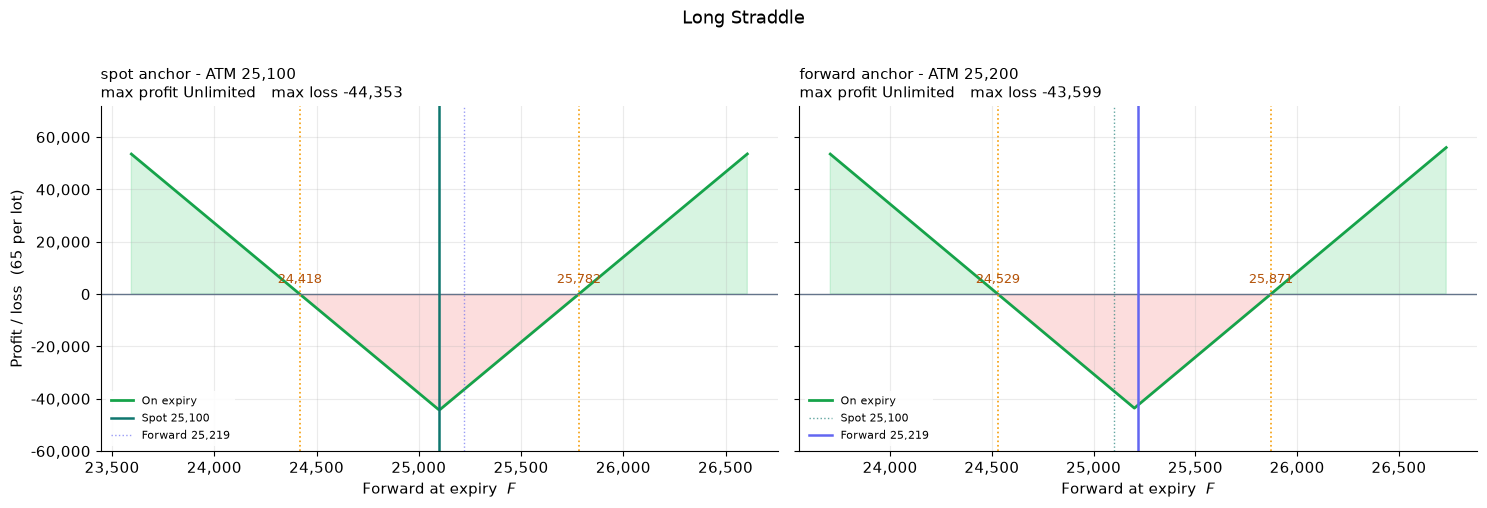

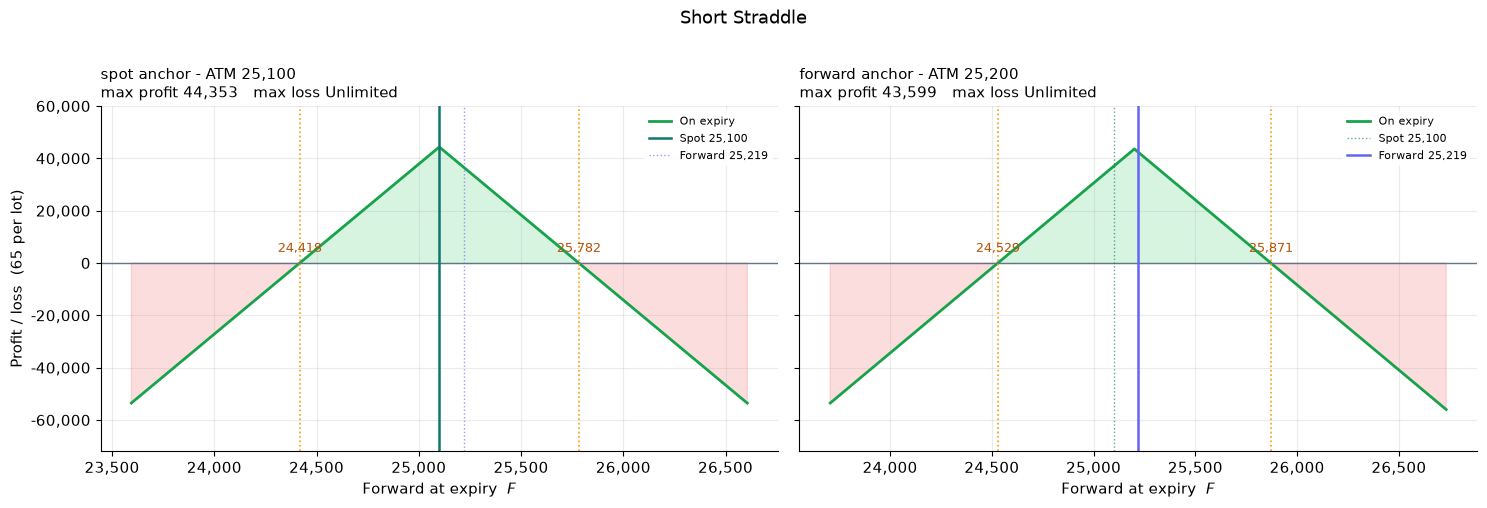

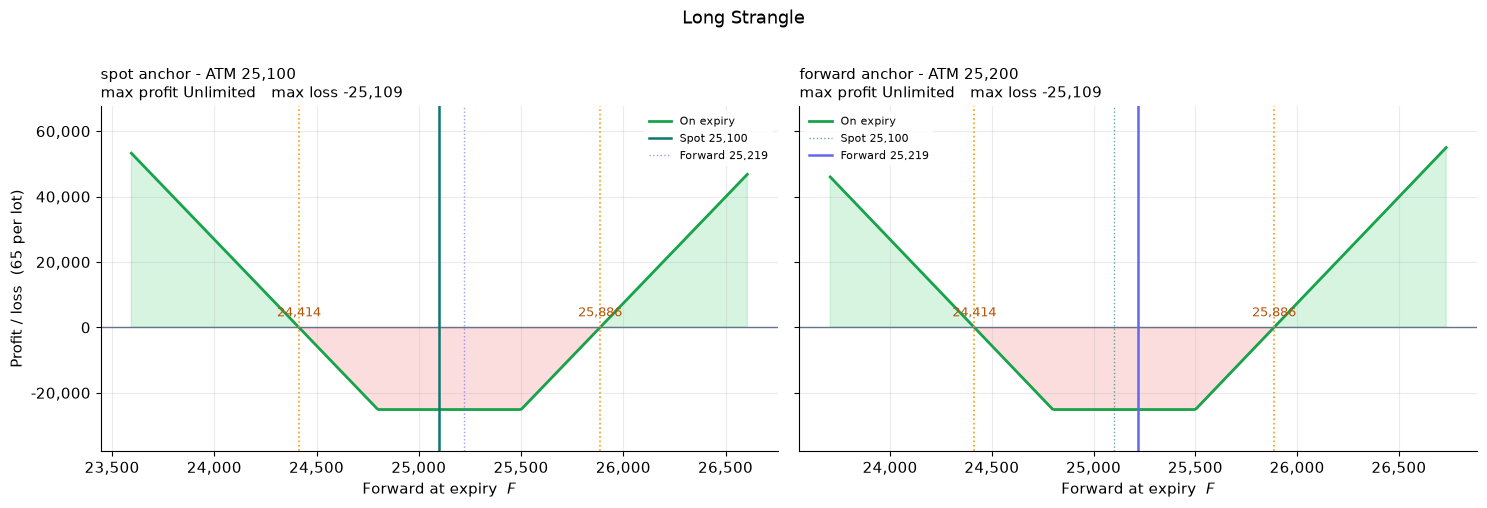

In [11]:
for name in ["Long Straddle", "Short Straddle", "Long Strangle"]:
    plot_pair(name)

### Vertical spreads — credit and debit

Two legs, same type, same expiry, different strikes $K_{\text{lo}} < K_{\text{hi}}$, opposite signs.
Every call is matched by a call and every put by a put, so

$$s_{\text{left}} = s_{\text{right}} = 0$$

Both tails flat: **defined risk on both sides**, with no wings to buy. The whole range is the width,

$$\text{max profit} - \text{max loss} = wL, \qquad w = K_{\text{hi}} - K_{\text{lo}}$$

and the premium decides where inside that range zero sits:

$$\textbf{credit:}\quad \text{max profit} = \text{credit}, \quad \text{max loss} = \text{credit} - wL$$
$$\textbf{debit:}\quad \text{max loss} = -\,\text{debit}, \quad \text{max profit} = wL - \text{debit}$$

One breakeven — the near strike moved by the premium per unit:

$$F^{*} = K_{\text{lo}} + \frac{|\text{net}|}{L} \;\;\text{(calls)}
\qquad
F^{*} = K_{\text{hi}} - \frac{|\text{net}|}{L} \;\;\text{(puts)}$$

Here $w = 300$ on both sides of 25200, so $wL = 300 \times 65 = 19{,}500$. On the spot-anchored
panel the call spread comes out **400 wide** instead — 25,400 CE is not quoted, so the short leg
lands at 25,500. The width is read off the strikes actually traded, never assumed.

**Bull Call Spread — debit.** Buy 25200 CE @ 344.05, sell 25500 CE @ 206.20.

$$\text{net} = (344.05 - 206.20) \times 65 = 137.85 \times 65 = 8{,}960.25 \quad\text{(debit)}$$
$$\text{max loss} = -8{,}960.25 \qquad \text{max profit} = 19{,}500 - 8{,}960.25 = 10{,}539.75$$
$$F^{*} = 25200 + 137.85 = 25{,}337.85$$

**Bear Call Spread — credit.** The same two strikes, signs reversed.

$$\text{credit} = 137.85 \times 65 = 8{,}960.25$$
$$\text{max profit} = 8{,}960.25 \qquad \text{max loss} = 8{,}960.25 - 19{,}500 = -10{,}539.75$$
$$F^{*} = 25{,}337.85$$

**Bull Put Spread — credit.** Sell 25200 PE @ 326.70, buy 24900 PE @ 208.05.

$$\text{credit} = (326.70 - 208.05) \times 65 = 118.65 \times 65 = 7{,}712.25$$
$$\text{max profit} = 7{,}712.25 \qquad \text{max loss} = 7{,}712.25 - 19{,}500 = -11{,}787.75$$
$$F^{*} = 25200 - 118.65 = 25{,}081.35$$

**Bear Put Spread — debit.** The same two strikes, signs reversed.

$$\text{debit} = 7{,}712.25$$
$$\text{max loss} = -7{,}712.25 \qquad \text{max profit} = 19{,}500 - 7{,}712.25 = 11{,}787.75$$
$$F^{*} = 25{,}081.35$$

Each credit/debit pair is an exact mirror: same $|\text{net}|$, same breakeven, caps swapped.
Selling a spread is buying the opposite one.

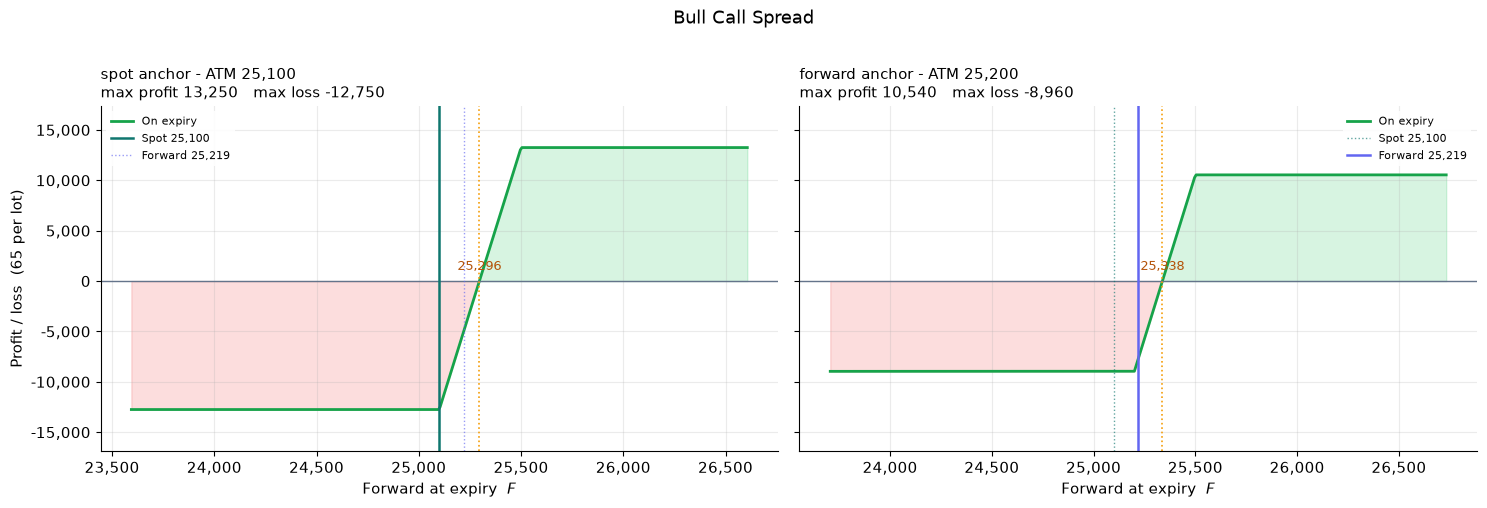

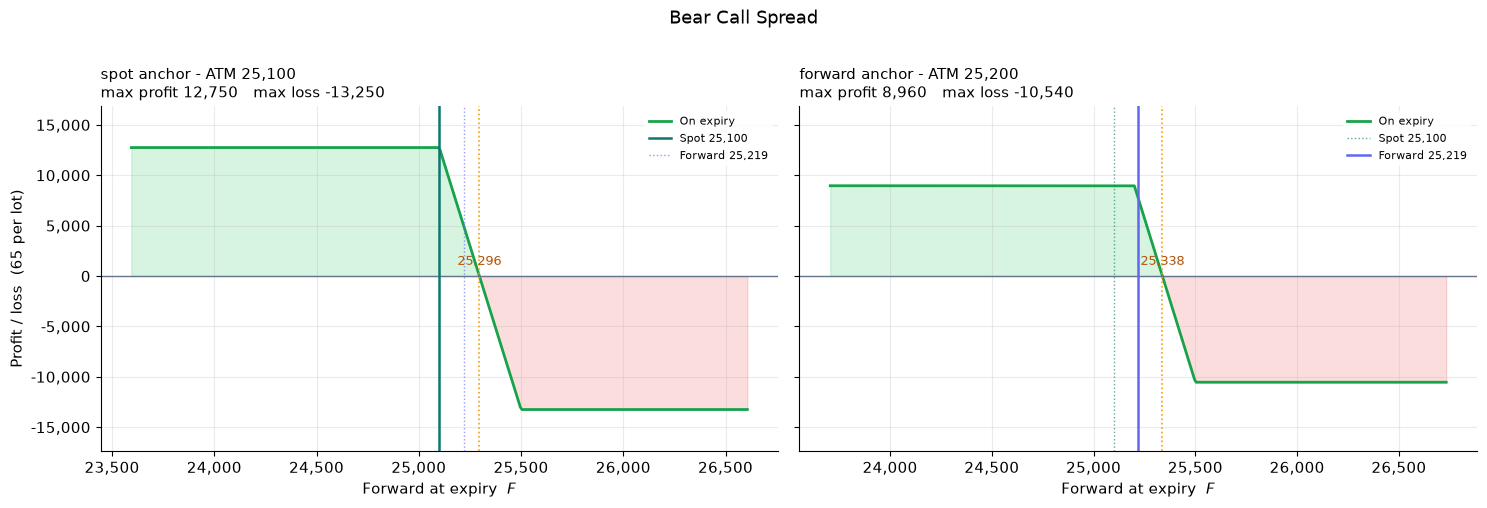

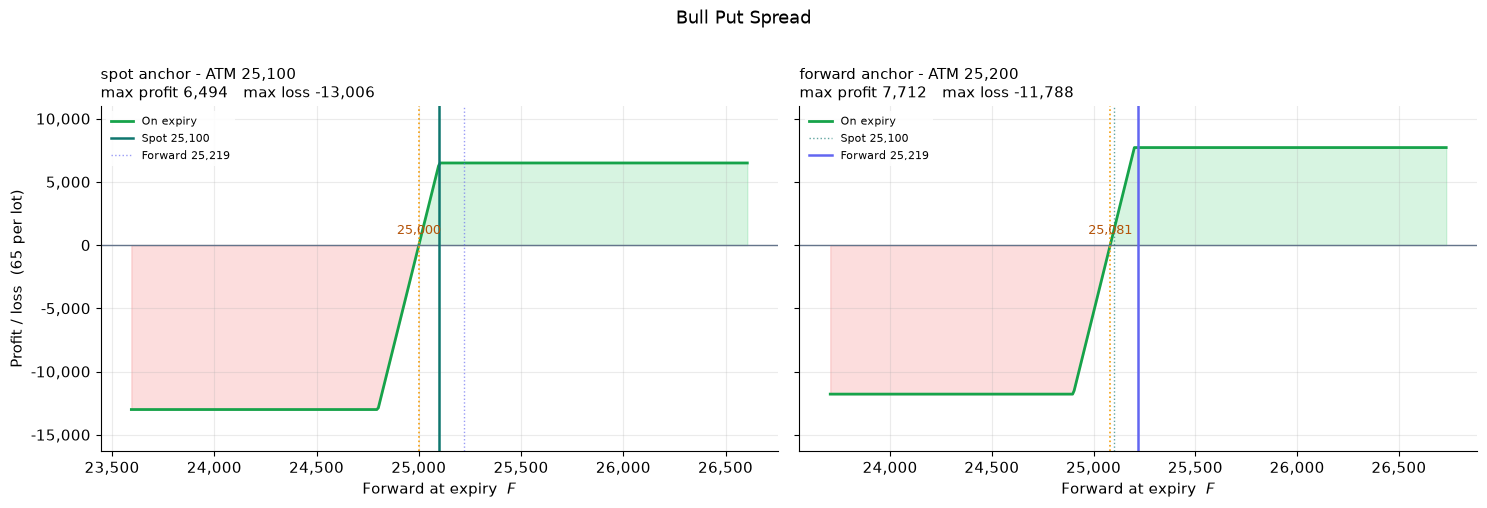

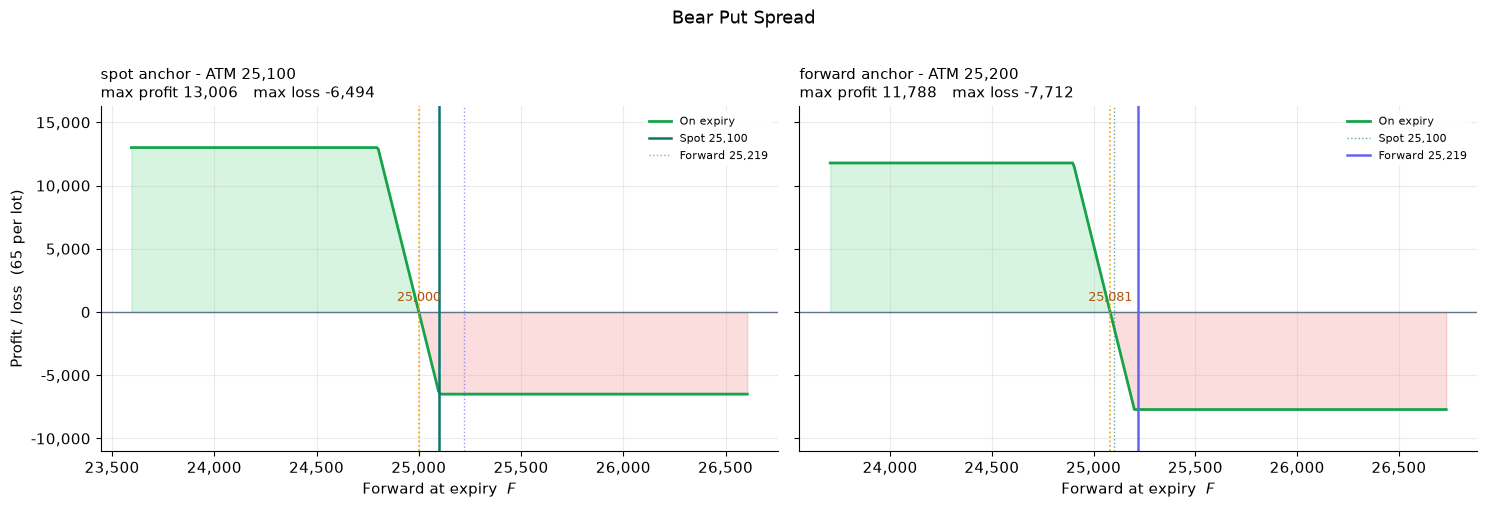

In [12]:
SPREADS = ["Bull Call Spread", "Bear Call Spread", "Bull Put Spread", "Bear Put Spread"]

for name in SPREADS:
    plot_pair(name)

#### Spread caps against the arithmetic

Every claim above, asserted against the engine for **both** anchors — the width relation, the
credit and debit caps, and the breakeven. These fail the notebook, and the `execute` CI job, if the
engine ever disagrees.

In [13]:
for anchor, A in ANCHORS.items():
    print(f"{anchor} anchor, ATM {A['atm']:,.0f}")
    for name in SPREADS:
        legs = A["strategies"][name]
        m = strategy_metrics(legs, LOT_SIZE)
        k_lo, k_hi = sorted(leg.strike for leg in legs)
        w = k_hi - k_lo
        span = w * LOT_SIZE
        net = m["net_premium"]

        assert m["left_slope"] == 0 and m["right_slope"] == 0, f"{name} has an open tail"
        assert abs((m["max_profit"] - m["max_loss"]) - span) < 1e-6, f"{name}: range != w x lot"

        if net < 0:
            credit, kind = -net, "credit"
            assert abs(m["max_profit"] - credit) < 1e-6, f"{name}: max profit != credit"
            assert abs(m["max_loss"] - (credit - span)) < 1e-6, f"{name}: max loss != credit - wL"
        else:
            kind = "debit"
            assert abs(m["max_loss"] + net) < 1e-6, f"{name}: max loss != -debit"
            assert abs(m["max_profit"] - (span - net)) < 1e-6, f"{name}: max profit != wL - debit"

        calls = all(leg.is_call for leg in legs)
        expected_be = k_lo + abs(net) / LOT_SIZE if calls else k_hi - abs(net) / LOT_SIZE
        assert len(m["breakevens"]) == 1, f"{name}: expected exactly one breakeven"
        assert abs(m["breakevens"][0] - expected_be) < 0.01, f"{name}: breakeven off formula"

        print(f"  {name:<18} {k_lo:,.0f}/{k_hi:,.0f}  w {w:>3,.0f} x {LOT_SIZE} = {span:>7,.0f}   "
              f"{abs(net):>9,.2f} {kind:<6}  "
              f"max profit {m['max_profit']:>10,.2f}   max loss {m['max_loss']:>11,.2f}   "
              f"breakeven {m['breakevens'][0]:,.2f}")
    print()

spot anchor, ATM 25,100
  Bull Call Spread   25,100/25,500  w 400 x 65 =  26,000   12,749.75 debit   max profit  13,250.25   max loss  -12,749.75   breakeven 25,296.15
  Bear Call Spread   25,100/25,500  w 400 x 65 =  26,000   12,749.75 credit  max profit  12,749.75   max loss  -13,250.25   breakeven 25,296.15
  Bull Put Spread    24,800/25,100  w 300 x 65 =  19,500    6,493.50 credit  max profit   6,493.50   max loss  -13,006.50   breakeven 25,000.10
  Bear Put Spread    24,800/25,100  w 300 x 65 =  19,500    6,493.50 debit   max profit  13,006.50   max loss   -6,493.50   breakeven 25,000.10

forward anchor, ATM 25,200
  Bull Call Spread   25,200/25,500  w 300 x 65 =  19,500    8,960.25 debit   max profit  10,539.75   max loss   -8,960.25   breakeven 25,337.85
  Bear Call Spread   25,200/25,500  w 300 x 65 =  19,500    8,960.25 credit  max profit   8,960.25   max loss  -10,539.75   breakeven 25,337.85
  Bull Put Spread    24,900/25,200  w 300 x 65 =  19,500    7,712.25 credit  max pro

### Iron condor and iron fly

Wings bought beyond each short leg turn what would otherwise be an unbounded loss into a known one.

- **Iron fly** — short ATM straddle, wings 300 points out.
- **Iron condor** — short strangle 300 out, wings 600 out.

Four legs each, no new code.

**Iron condor** — sell 25500 CE @ 206.20 and 24900 PE @ 208.05, buy 25800 CE @ 115.60 and
24600 PE @ 130.20.

$$-206.20 - 208.05 + 115.60 + 130.20 = -168.45
\;\Rightarrow\; -168.45 \times 65 = -10{,}949.25 \quad \text{(credit)}$$

Both wings bought $\Rightarrow s_{\text{left}} = s_{\text{right}} = 0$: both tails flat, both caps
finite.

$$\text{max profit} = \text{credit} = 10{,}949.25$$

$$\text{max loss} = \text{credit} - wL = 10{,}949.25 - 300 \times 65 = -8{,}550.75$$

The credit erodes outward from each short strike:

$$24900 - 168.45 = 24{,}731.55 \qquad 25500 + 168.45 = 25{,}668.45$$

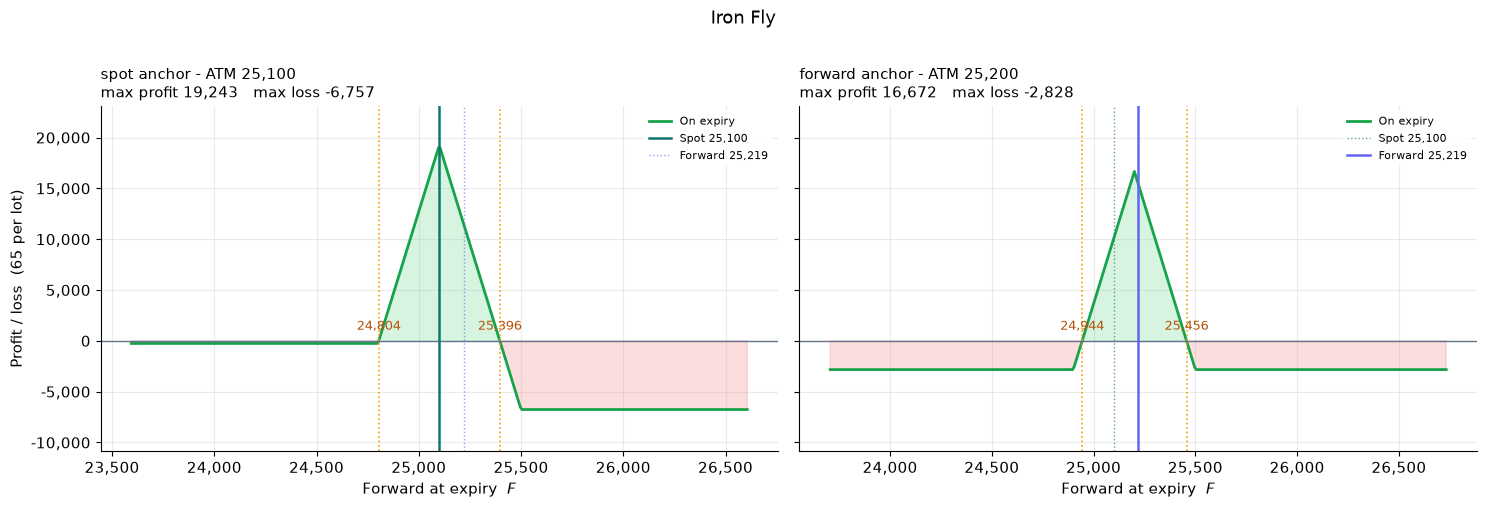

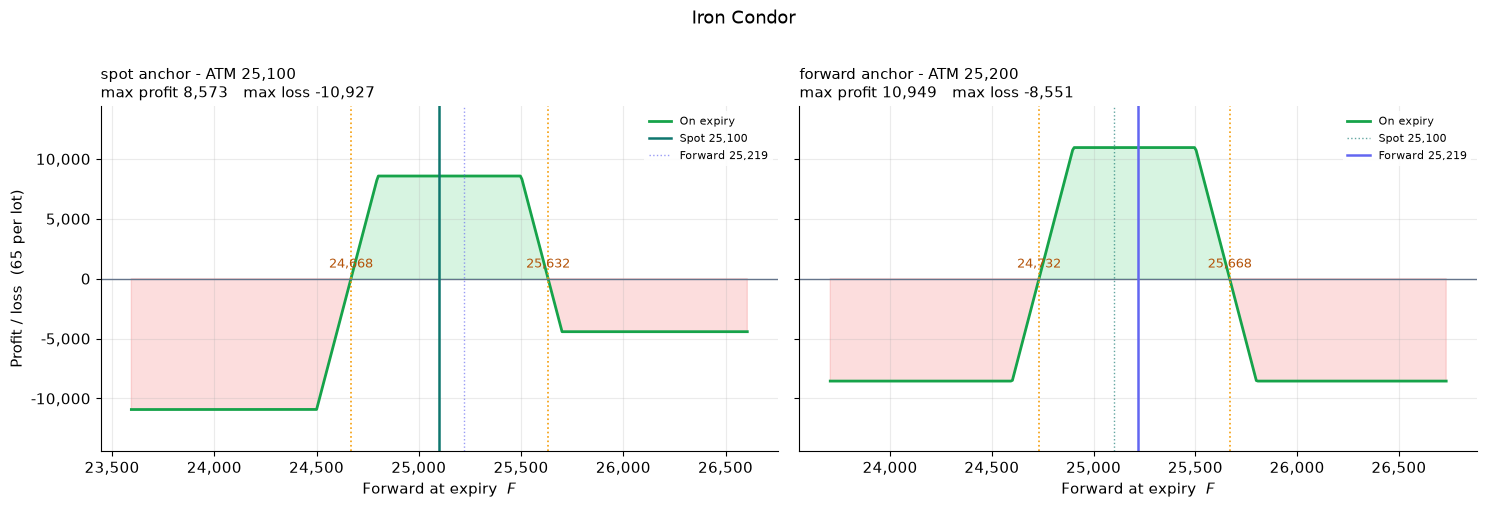

In [14]:
for name in ["Iron Fly", "Iron Condor"]:
    plot_pair(name)

#### Caps against the arithmetic

For a credit structure with both tails flat, the caps are forced by the wings:

$$\text{max profit} = \text{credit}
\qquad
\text{max loss} = \text{credit} - w_{\max} L,
\qquad w_{\max} = \max\bigl(w_{\text{left}},\, w_{\text{right}}\bigr)$$

The **wider** wing sets the loss. The two tails are flat at $\text{credit} - w_{\text{left}}L$ and
$\text{credit} - w_{\text{right}}L$, and the cap is the lower of them.

$w_{\max}$ is not decoration. Under the forward anchor both structures come out symmetric and it
collapses to plain $w$ — but under the spot anchor they do not, because **25,400 CE is not quoted**:
the fly's call wing lands at 25,500, 400 points out against 300 on the put side. The left-hand panel
needs the general form.

In [15]:
for anchor, A in ANCHORS.items():
    s = A["strikes"]
    print(f"{anchor} anchor, ATM {s['atm']:,.0f}")
    for name, put_width, call_width in [
        ("Iron Fly",    s["atm"] - s["fly_put"],      s["fly_call"] - s["atm"]),
        ("Iron Condor", s["fly_put"] - s["con_put"],  s["con_call"] - s["fly_call"]),
    ]:
        m = strategy_metrics(A["strategies"][name], LOT_SIZE)

        credit = -m["net_premium"]                   # net_premium is negative when we are paid
        w_max = max(put_width, call_width)
        risk = w_max * LOT_SIZE
        expected_loss = credit - risk

        assert m["left_slope"] == 0 and m["right_slope"] == 0, f"{name} has an open tail"
        assert abs(m["max_profit"] - credit) < 1e-6, f"{name}: max profit != credit"
        assert abs(m["max_loss"] - expected_loss) < 1e-6, f"{name}: max loss != credit - w_max x lot"

        symmetry = "symmetric" if put_width == call_width else "ASYMMETRIC"
        print(f"  {name}")
        print(f"    wings        {put_width:,.0f} put / {call_width:,.0f} call   ({symmetry}), "
              f"w_max {w_max:,.0f} x {LOT_SIZE} = {risk:,.2f}")
        print(f"    net credit   {credit:,.2f}")
        print(f"    max profit   {m['max_profit']:,.2f}   = credit")
        print(f"    max loss     {m['max_loss']:,.2f}   = credit - w_max x lot")
        print(f"    breakevens   {m['breakevens']}")
        print(f"    risk/reward  1 : {credit / -m['max_loss']:.2f}")
    print()

spot anchor, ATM 25,100
  Iron Fly
    wings        300 put / 400 call   (ASYMMETRIC), w_max 400 x 65 = 26,000.00
    net credit   19,243.25
    max profit   19,243.25   = credit
    max loss     -6,756.75   = credit - w_max x lot
    breakevens   [24803.95, 25396.05]
    risk/reward  1 : 2.85
  Iron Condor
    wings        300 put / 200 call   (ASYMMETRIC), w_max 300 x 65 = 19,500.00
    net credit   8,573.50
    max profit   8,573.50   = credit
    max loss     -10,926.50   = credit - w_max x lot
    breakevens   [24668.1, 25631.9]
    risk/reward  1 : 0.78

forward anchor, ATM 25,200
  Iron Fly
    wings        300 put / 300 call   (symmetric), w_max 300 x 65 = 19,500.00
    net credit   16,672.50
    max profit   16,672.50   = credit
    max loss     -2,827.50   = credit - w_max x lot
    breakevens   [24943.5, 25456.5]
    risk/reward  1 : 5.90
  Iron Condor
    wings        300 put / 300 call   (symmetric), w_max 300 x 65 = 19,500.00
    net credit   10,949.25
    max profit   10

### Naked call and put

The building blocks. One leg each, same two functions.

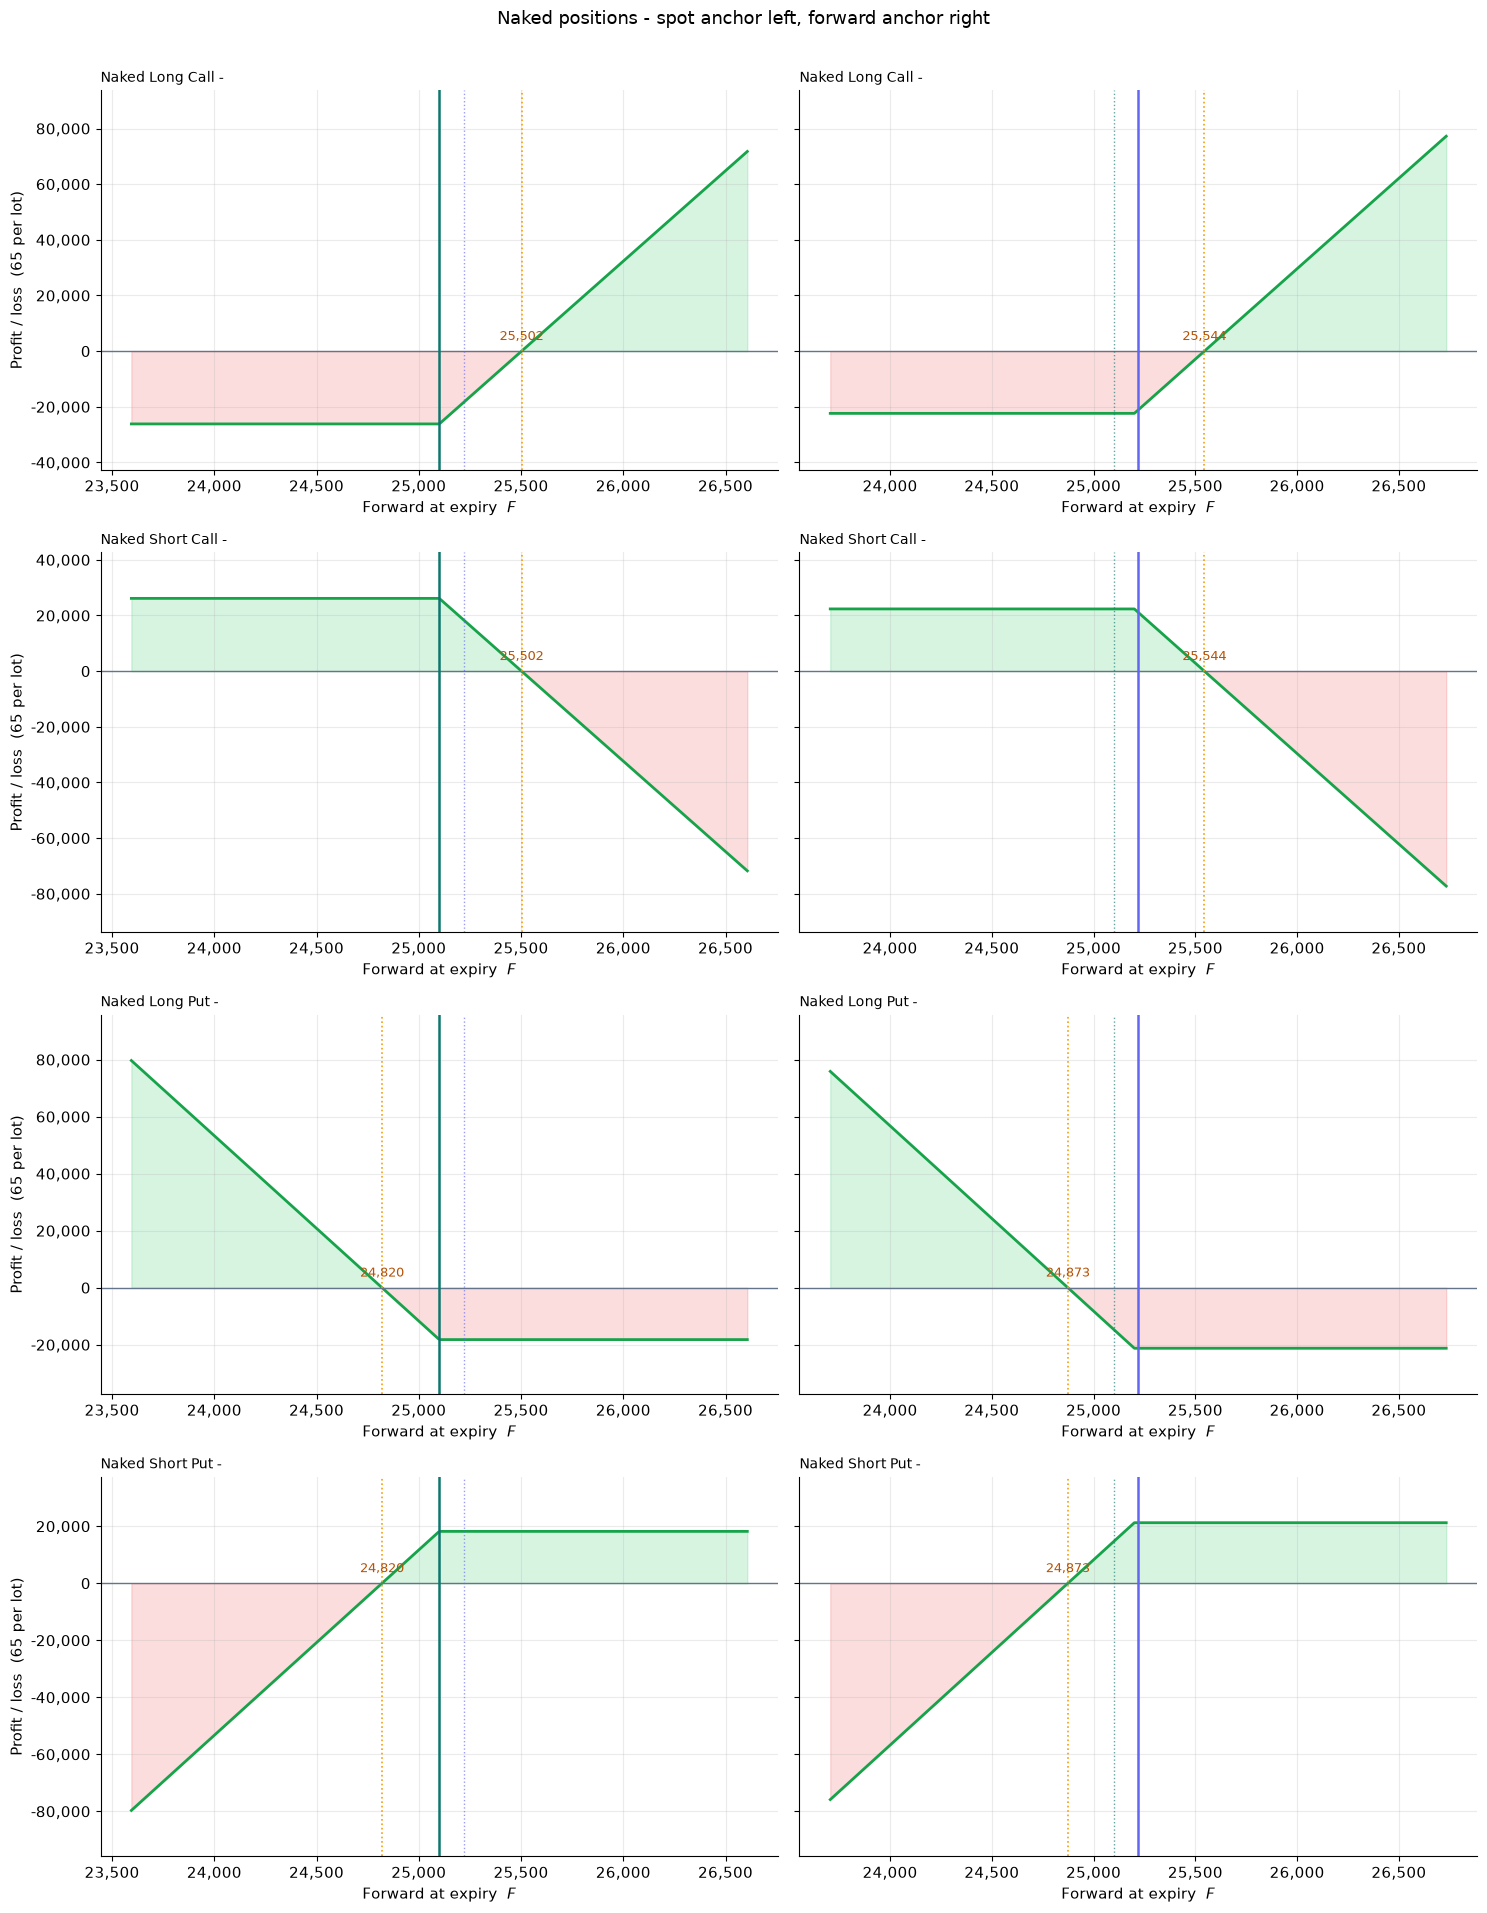

In [16]:
NAKED = ["Naked Long Call", "Naked Short Call", "Naked Long Put", "Naked Short Put"]

fig, axes = plt.subplots(4, 2, figsize=(15, 19), sharey="row")
for row, name in zip(axes, NAKED):
    for ax, anchor in zip(row, ("spot", "forward")):
        plot_strategy(name, anchor, ax=ax)
        ax.legend().remove()
        ax.set_title(f"{name} - {ax.get_title()}", fontsize=10, loc="left")
    row[1].set_ylabel("")
fig.suptitle("Naked positions - spot anchor left, forward anchor right", fontsize=13, y=1.005)
fig.tight_layout()
plt.show()

## 8. Summary

Every structure at both anchors. `Dr` is a debit paid, `Cr` a credit received.

In [17]:
rows = []
for anchor, A in ANCHORS.items():
    for name, legs in A["strategies"].items():
        m = strategy_metrics(legs, LOT_SIZE)
        rows.append({
            "Anchor": anchor,
            "Strategy": name,
            "Legs": ", ".join(repr(leg) for leg in legs),
            "Max Profit": fmt(m["max_profit"]),
            "Max Loss": fmt(m["max_loss"]),
            "Breakeven(s)": ", ".join(f"{b:,.0f}" for b in m["breakevens"]) or "-",
            "Net Premium": f"{abs(m['net_premium']):,.0f} {'Dr' if m['net_premium'] > 0 else 'Cr'}",
        })

summary = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 60)
summary

,Anchor,Strategy,Legs,Max Profit,Max Loss,Breakeven(s),Net Premium
0,spot,Long Straddle,"B 1x 25100 CE @ 402.35, B 1x 25100 PE @ 280.00",Unlimited,"-44,353","24,418, 25,782","44,353 Dr"
1,spot,Short Straddle,"S 1x 25100 CE @ 402.35, S 1x 25100 PE @ 280.00","44,353",Unlimited,"24,418, 25,782","44,353 Cr"
2,spot,Long Strangle,"B 1x 25500 CE @ 206.20, B 1x 24800 PE @ 180.10",Unlimited,"-25,109","24,414, 25,886","25,109 Dr"
3,spot,Bull Call Spread,"B 1x 25100 CE @ 402.35, S 1x 25500 CE @ 206.20","13,250","-12,750","25,296","12,750 Dr"
4,spot,Bear Call Spread,"S 1x 25100 CE @ 402.35, B 1x 25500 CE @ 206.20","12,750","-13,250","25,296","12,750 Cr"
5,spot,Bull Put Spread,"S 1x 25100 PE @ 280.00, B 1x 24800 PE @ 180.10","6,494","-13,006","25,000","6,494 Cr"
6,spot,Bear Put Spread,"B 1x 25100 PE @ 280.00, S 1x 24800 PE @ 180.10","13,006","-6,494","25,000","6,494 Dr"
7,spot,Iron Fly,"S 1x 25100 CE @ 402.35, S 1x 25100 PE @ 280.00, B 1x 255...","19,243","-6,757","24,804, 25,396","19,243 Cr"
8,spot,Iron Condor,"S 1x 25500 CE @ 206.20, S 1x 24800 PE @ 180.10, B 1x 257...","8,573","-10,927","24,668, 25,632","8,573 Cr"
9,spot,Naked Long Call,B 1x 25100 CE @ 402.35,Unlimited,"-26,153","25,502","26,153 Dr"


### What the anchor costs

The same nominal structure, priced off spot instead of the forward, is a different trade. The
table below is the forward-anchored figure minus the spot-anchored one for each structure — the
basis is only 118.87 points, and it moves every number that matters.

The long strangle is the one exception: its legs are chosen 300 points out from the anchor, and
both anchors round to the same pair of quoted strikes, so it is genuinely the same position. That
is a property of this chain's gaps, not a rule.

In [18]:
comparison = []
for name in STRATEGIES_FWD:
    mf = strategy_metrics(STRATEGIES_FWD[name], LOT_SIZE)
    ms = strategy_metrics(STRATEGIES_SPOT[name], LOT_SIZE)
    same = [leg.strike for leg in STRATEGIES_FWD[name]] == [leg.strike for leg in STRATEGIES_SPOT[name]]
    comparison.append({
        "Strategy": name,
        "Same legs": "yes" if same else "no",
        "Net (fwd)": f"{mf['net_premium']:,.0f}",
        "Net (spot)": f"{ms['net_premium']:,.0f}",
        "d Net": f"{mf['net_premium'] - ms['net_premium']:+,.0f}",
        "Max Profit (fwd)": fmt(mf["max_profit"]),
        "Max Profit (spot)": fmt(ms["max_profit"]),
        "Max Loss (fwd)": fmt(mf["max_loss"]),
        "Max Loss (spot)": fmt(ms["max_loss"]),
    })

pd.DataFrame(comparison)

,Strategy,Same legs,Net (fwd),Net (spot),d Net,Max Profit (fwd),Max Profit (spot),Max Loss (fwd),Max Loss (spot)
0,Long Straddle,no,"43,599","44,353",-754,Unlimited,Unlimited,"-43,599","-44,353"
1,Short Straddle,no,"-43,599","-44,353",+754,"43,599","44,353",Unlimited,Unlimited
2,Long Strangle,yes,"25,109","25,109",+0,Unlimited,Unlimited,"-25,109","-25,109"
3,Bull Call Spread,no,"8,960","12,750","-3,790","10,540","13,250","-8,960","-12,750"
4,Bear Call Spread,no,"-8,960","-12,750","+3,790","8,960","12,750","-10,540","-13,250"
5,Bull Put Spread,no,"-7,712","-6,494","-1,219","7,712","6,494","-11,788","-13,006"
6,Bear Put Spread,no,"7,712","6,494","+1,219","11,788","13,006","-7,712","-6,494"
7,Iron Fly,no,"-16,672","-19,243","+2,571","16,672","19,243","-2,828","-6,757"
8,Iron Condor,no,"-10,949","-8,573","-2,376","10,949","8,573","-8,551","-10,927"
9,Naked Long Call,no,"22,363","26,153","-3,790",Unlimited,Unlimited,"-22,363","-26,153"
